# 06 — Decision

**Tujuan:** menentukan label `MATCH / REVIEW / NON-MATCH` per candidate pair
berdasarkan `match_probability` dari Notebook 04, dan mendokumentasikan
keterbatasan threshold yang ada secara jujur.

**Konteks penting sebelum membaca notebook ini:**

Dari Notebook 04 diketahui bahwa probability **sangat saturated**:
- 1.867 dari 1.868 pairs (99.9%) punya `match_probability` ≥ 0.999
- 1 pair punya probability < 0.10
- Tidak ada pair di zona 0.10 – 0.99

Konsekuensinya: **threshold berapapun yang dipilih di antara 0.10 dan 0.999
akan menghasilkan hasil yang identik** — semua 1.867 pairs = MATCH.
Threshold 0.85 / 0.20 dari Notebook 04 bukan threshold yang dikalibrasi,
hanya titik referensi baseline.

Notebook ini mendokumentasikan kondisi ini secara eksplisit (sesuai Rule 5
di master prompt: threshold tidak boleh ditetapkan asal dan disebut optimal),
menganalisis apa yang bisa diekstrak dari hasil yang ada, dan menentukan
langkah yang diperlukan sebelum threshold bisa dikalibrasi dengan benar.

## 1. Imports & paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
PRED_PATH      = r"C:\Users\User\Downloads\Fix\data\raw\splink_predictions.csv"
ENTITY_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\splink_entities.csv"
DECISION_PATH  = r"C:\Users\User\Downloads\Fix\data\raw\decided_matches.csv"
CLUSTER_ANALYSIS_PATH = r"C:\Users\User\Downloads\Fix\data\raw\cluster_analysis.csv"
PRED_RELAXED_PATH      = r"C:\Users\User\Downloads\Fix\data\raw\splink_predictions_relaxed.csv"
ENTITY_RELAXED_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\splink_entities_relaxed.csv"
DECISION_RELAXED_PATH  = r"C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed.csv"
CLUSTER_RELAXED_PATH   = r"C:\Users\User\Downloads\Fix\data\raw\cluster_analysis_relaxed.csv"
PROB_DIST_RELAXED_PNG  = r"C:\Users\User\Downloads\Fix\data\raw\probability_distribution_relaxed.png"

## 2. Load predictions & clusters

In [3]:
pred     = pd.read_csv(PRED_PATH, dtype=str)
clusters = pd.read_csv(ENTITY_PATH, dtype=str)

pred['match_probability'] = pred['match_probability'].astype(float)

print(f"Predictions : {len(pred):,} rows")
print(f"Clusters    : {len(clusters):,} rows, "
      f"{clusters['cluster_id'].nunique():,} unique cluster_id")

# Rekonfirmasi distribusi probability
print("\nMatch probability describe:")
print(pred['match_probability'].describe())

Predictions : 1,868 rows
Clusters    : 50,000 rows, 48,200 unique cluster_id

Match probability describe:
count    1.868000e+03
mean     9.994647e-01
std      2.313724e-02
min      1.482023e-09
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: match_probability, dtype: float64


## 3. Visualisasi distribusi probability

Ditampilkan dalam dua skala: linear dan log-scale Y-axis.
Log-scale penting karena dengan distribusi saturated seperti ini,
skala linear menyembunyikan 1 pair yang ada di prob < 0.10.

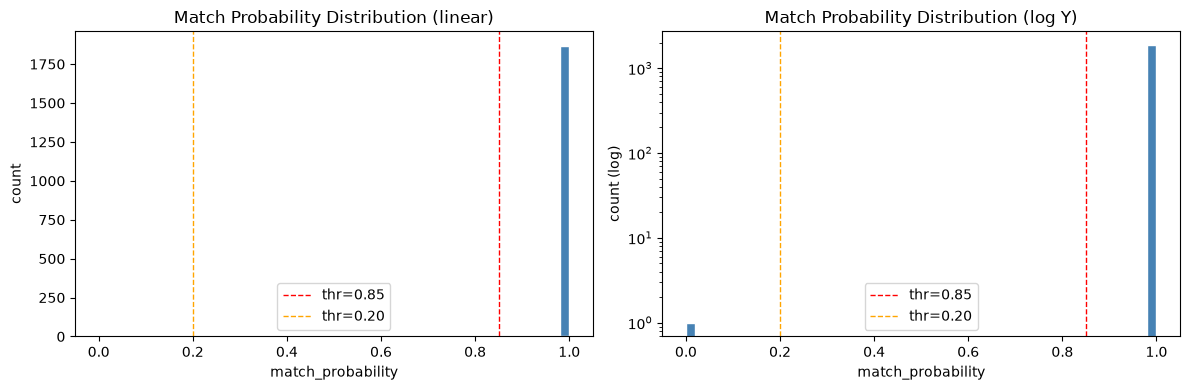

Plot saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear
axes[0].hist(pred['match_probability'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Match Probability Distribution (linear)')
axes[0].set_xlabel('match_probability')
axes[0].set_ylabel('count')
axes[0].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[0].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[0].legend()

# Log-scale Y
axes[1].hist(pred['match_probability'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Match Probability Distribution (log Y)')
axes[1].set_xlabel('match_probability')
axes[1].set_ylabel('count (log)')
axes[1].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[1].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\User\Downloads\Fix\data\raw\probability_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 4. Threshold sensitivity analysis

Karena probability saturated, tabel berikut membuktikan secara kuantitatif
bahwa **hampir semua threshold di atas 0.10 menghasilkan hasil identik**.
Ini bukan kesimpulan asumsi — ini dihitung langsung dari data.

In [5]:
thresholds = [0.30 ,0.40, 0.50, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99, 0.999]
rows = []
total = len(pred)
for thr in thresholds:
    n_match    = (pred['match_probability'] >= thr).sum()
    n_nonmatch = total - n_match
    rows.append({
        'threshold'          : thr,
        'MATCH'              : n_match,
        'NON-MATCH'          : n_nonmatch,
        'MATCH_%'            : round(n_match / total * 100, 2),
    })

sens_df = pd.DataFrame(rows)
print("Threshold sensitivity (dengan probability distribusi saat ini):")
print(sens_df.to_string(index=False))
print("\nKesimpulan: threshold pada saat ini menghasilkan MATCH count yang identik.")
print("Threshold hanya bermakna setelah probability terdistribusi lebih merata,")
print("yaitu setelah candidate set diperluas dengan genuine non-match pairs.")

Threshold sensitivity (dengan probability distribusi saat ini):
 threshold  MATCH  NON-MATCH  MATCH_%
     0.300   1867          1    99.95
     0.400   1867          1    99.95
     0.500   1867          1    99.95
     0.700   1867          1    99.95
     0.800   1867          1    99.95
     0.850   1867          1    99.95
     0.900   1867          1    99.95
     0.950   1867          1    99.95
     0.990   1867          1    99.95
     0.999   1867          1    99.95

Kesimpulan: threshold pada saat ini menghasilkan MATCH count yang identik.
Threshold hanya bermakna setelah probability terdistribusi lebih merata,
yaitu setelah candidate set diperluas dengan genuine non-match pairs.


## 5. Apply decision label

Threshold 0.85 / 0.20 dipertahankan sebagai **baseline dokumentasi**.
Label `REVIEW` tidak akan terisi dengan distribusi probability saat ini
(tidak ada pair di zona 0.20–0.85), tapi strukturnya dipertahankan
agar Notebook 07 bisa memakai file ini tanpa perubahan format
ketika threshold sudah dikalibrasi nanti.

In [6]:
THRESHOLD_MATCH     = 0.85  # BASELINE belum dikalibrasi
THRESHOLD_NONMATCH  = 0.20  # BASELINE belum dikalibrasi

def decide(prob):
    if prob >= THRESHOLD_MATCH:
        return 'MATCH'
    elif prob >= THRESHOLD_NONMATCH:
        return 'REVIEW'
    else:
        return 'NON-MATCH'

pred['decision'] = pred['match_probability'].apply(decide)
pred['threshold_match_used']    = THRESHOLD_MATCH
pred['threshold_nonmatch_used'] = THRESHOLD_NONMATCH

print("Decision distribution (threshold BASELINE 0.85 / 0.20):")
print(pred['decision'].value_counts().to_string())
print(f"\nTotal pairs  : {len(pred):,}")
print(f"MATCH        : {(pred['decision']=='MATCH').sum():,}")
print(f"REVIEW       : {(pred['decision']=='REVIEW').sum():,}")
print(f"NON-MATCH    : {(pred['decision']=='NON-MATCH').sum():,}")

Decision distribution (threshold BASELINE 0.85 / 0.20):
decision
MATCH        1867
NON-MATCH       1

Total pairs  : 1,868
MATCH        : 1,867
REVIEW       : 0
NON-MATCH    : 1


## 6. Analisis cluster

Cluster dari Notebook 04 (threshold=0.80) dianalisis lebih dalam:
- Berapa entity yang terbentuk
- Distribusi ukuran cluster
- Cluster besar (>2 record) perlu diinspeksi manual — potensi over-merge

In [7]:
cluster_sizes = clusters.groupby('cluster_id').size().reset_index(name='cluster_size')
clusters_with_size = clusters.merge(cluster_sizes, on='cluster_id')

print("Ringkasan cluster (threshold=0.80):")
print(f"  Total rows          : {len(clusters):,}")
print(f"  Unique cluster_id   : {clusters['cluster_id'].nunique():,}")
print(f"  Singleton (size=1)  : {(cluster_sizes['cluster_size']==1).sum():,}")
print(f"  Cluster size 2      : {(cluster_sizes['cluster_size']==2).sum():,}")
print(f"  Cluster size 3      : {(cluster_sizes['cluster_size']==3).sum():,}")
print(f"  Cluster size 4      : {(cluster_sizes['cluster_size']==4).sum():,}")
print(f"  Cluster size >4     : {(cluster_sizes['cluster_size']>4).sum():,}")

Ringkasan cluster (threshold=0.80):
  Total rows          : 50,000
  Unique cluster_id   : 48,200
  Singleton (size=1)  : 46,466
  Cluster size 2      : 1,669
  Cluster size 3      : 64
  Cluster size 4      : 1
  Cluster size >4     : 0


In [8]:
# Inspeksi cluster ukuran ≥ 3 (kandidat over-merge)
large_clusters = cluster_sizes[cluster_sizes['cluster_size'] >= 3].sort_values(
    'cluster_size', ascending=False
)
print(f"Cluster ukuran ≥ 3: {len(large_clusters)} cluster")
print(large_clusters.head(10).to_string(index=False))

# Ambil contoh satu cluster ukuran terbesar untuk inspeksi manual
if len(large_clusters) > 0:
    biggest_cid = large_clusters.iloc[0]['cluster_id']
    sample_big  = clusters_with_size[clusters_with_size['cluster_id'] == biggest_cid]
    print(f"\nContoh cluster terbesar (cluster_id={biggest_cid}):")
    print(sample_big[['unique_id', 'cluster_id', 'cluster_size', 'customer_id']].to_string(index=False))
    print("\nCatatan: kalau customer_id berbeda di dalam satu cluster ukuran ≥ 3,")
    print("bisa jadi over-merge (entity berbeda digabung) -- perlu dicek di Notebook 06.")

Cluster ukuran ≥ 3: 65 cluster
cluster_id  cluster_size
     10077             4
     10120             3
     10261             3
     11339             3
     11350             3
     11573             3
     12821             3
     12867             3
     12905             3
     13608             3

Contoh cluster terbesar (cluster_id=10077):
unique_id cluster_id  cluster_size                          customer_id
    11899      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    10077      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    23776      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    40059      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6

Catatan: kalau customer_id berbeda di dalam satu cluster ukuran ≥ 3,
bisa jadi over-merge (entity berbeda digabung) -- perlu dicek di Notebook 06.


## 7. Inspeksi pair dengan probability rendah

Ada 1 pair dengan `match_probability` < 0.10 — ini satu-satunya pair yang
berpotensi sebagai genuine non-match di candidate set kita. Perlu dilihat
apa yang membuat pair ini berbeda dari 1.867 pair lainnya.

In [9]:
low_prob = pred[pred['match_probability'] < 0.10].copy()
print(f"Pairs prob < 0.10: {len(low_prob)}")
if len(low_prob) > 0:
    cols_show = ['unique_id_l', 'unique_id_r', 'match_probability', 'decision',
                 'customer_id_l', 'customer_id_r']
    available = [c for c in cols_show if c in low_prob.columns]
    print(low_prob[available].to_string(index=False))
    same = (low_prob['customer_id_l'] == low_prob['customer_id_r']).sum()
    print(f"\nSame customer_id: {same} dari {len(low_prob)} pair")
    print("Jika customer_id berbeda: ini genuine non-match yang masuk blocking rules.")
    print("Jika customer_id sama: ini duplicate yang seharusnya match tapi model salah.")

Pairs prob < 0.10: 1
unique_id_l unique_id_r  match_probability  decision                        customer_id_l                        customer_id_r
      29535       31225       1.482023e-09 NON-MATCH 633b962f-89d7-42be-b6fe-05b69240df13 d5e5bb01-6f67-4e07-8a62-06d4555aa1e8

Same customer_id: 0 dari 1 pair
Jika customer_id berbeda: ini genuine non-match yang masuk blocking rules.
Jika customer_id sama: ini duplicate yang seharusnya match tapi model salah.


## 8. Simpan output

In [10]:
# decided_matches.csv: semua pairs dengan label decision
pred.to_csv(DECISION_PATH, index=False)
print(f"Saved: {DECISION_PATH} ({len(pred):,} rows)")

# cluster_analysis.csv: clusters + ukuran cluster
clusters_with_size.to_csv(CLUSTER_ANALYSIS_PATH, index=False)
print(f"Saved: {CLUSTER_ANALYSIS_PATH} ({len(clusters_with_size):,} rows)")

Saved: C:\Users\User\Downloads\Fix\data\raw\decided_matches.csv (1,868 rows)


Saved: C:\Users\User\Downloads\Fix\data\raw\cluster_analysis.csv (50,000 rows)


## 9. Relaxed pipeline (file baru, baseline tidak di-overwrite)

Blocking rule ke-5 (`block_on(phone_main_std)` saja, tanpa dob) di Notebook 04 menambah candidate set: 1.868 → ~5.741 pairs (+3.873 hard negatives, phone sama tapi dob/nama/email berbeda). Coverage tetap 100% karena union monoton naik (baseline rules sudah cover semua 1.867 duplikat). Threshold baseline 0.85/0.20 diterapkan ulang ke `splink_predictions_relaxed.csv` dan disimpan sebagai file BARU `decided_matches_relaxed.csv`.

In [11]:
pred_rel = pd.read_csv(PRED_RELAXED_PATH, dtype=str)
pred_rel['match_probability'] = pred_rel['match_probability'].astype(float)
pred_rel['match_weight'] = pred_rel['match_weight'].astype(float)

print(f"Relaxed predictions : {len(pred_rel):,} rows")
print(f"Same-customer       : {(pred_rel['is_same_customer']=='1').sum():,}")
print(f"Diff-customer       : {(pred_rel['is_same_customer']=='0').sum():,}")
print("\nRelaxed probability describe:")
print(pred_rel['match_probability'].describe())
print(f"\nProb >= 0.999            : {(pred_rel['match_probability']>=0.999).sum():,}")
print(f"Prob < 0.80              : {(pred_rel['match_probability']<0.80).sum():,}")
print(f"REVIEW zone (0.20-0.80)  : {((pred_rel['match_probability']>=0.20)&(pred_rel['match_probability']<0.80)).sum():,}")

Relaxed predictions : 17,485 rows
Same-customer       : 1,867
Diff-customer       : 15,618

Relaxed probability describe:
count    17485.000000
mean         0.107924
std          0.309681
min          0.000007
25%          0.000047
50%          0.000123
75%          0.000434
max          1.000000
Name: match_probability, dtype: float64

Prob >= 0.999            : 1,868
Prob < 0.80              : 15,606
REVIEW zone (0.20-0.80)  : 5


### 9a. Distribusi probability relaxed (linear + log Y)

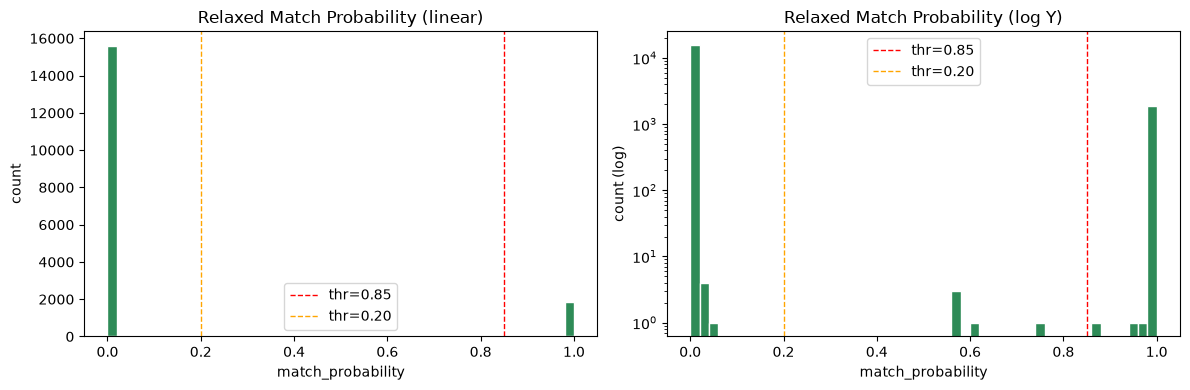

Plot saved: C:\Users\User\Downloads\Fix\data\raw\probability_distribution_relaxed.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_rel['match_probability'], bins=50, color='seagreen', edgecolor='white')
axes[0].set_title('Relaxed Match Probability (linear)')
axes[0].set_xlabel('match_probability')
axes[0].set_ylabel('count')
axes[0].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[0].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[0].legend()

axes[1].hist(pred_rel['match_probability'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Relaxed Match Probability (log Y)')
axes[1].set_xlabel('match_probability')
axes[1].set_ylabel('count (log)')
axes[1].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[1].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROB_DIST_RELAXED_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved: {PROB_DIST_RELAXED_PNG}")

### 9b. Threshold sensitivity relaxed

In [13]:
thresholds = [0.50, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99, 0.999]
rows = []
total_rel = len(pred_rel)
for thr in thresholds:
    n_match    = (pred_rel['match_probability'] >= thr).sum()
    n_nonmatch = total_rel - n_match
    rows.append({
        'threshold' : thr,
        'MATCH'     : n_match,
        'NON-MATCH' : n_nonmatch,
        'MATCH_%'   : round(n_match / total_rel * 100, 2),
    })

print("Threshold sensitivity (RELAXED candidate set):")
print(pd.DataFrame(rows).to_string(index=False))

Threshold sensitivity (RELAXED candidate set):
 threshold  MATCH  NON-MATCH  MATCH_%
     0.500   1884      15601    10.77
     0.700   1880      15605    10.75
     0.800   1879      15606    10.75
     0.850   1879      15606    10.75
     0.900   1878      15607    10.74
     0.950   1878      15607    10.74
     0.990   1873      15612    10.71
     0.999   1868      15617    10.68


### 9c. Decision + match-weight gap relaxed

In [14]:
pred_rel['decision'] = pred_rel['match_probability'].apply(decide)
pred_rel['threshold_match_used']    = THRESHOLD_MATCH
pred_rel['threshold_nonmatch_used'] = THRESHOLD_NONMATCH

print("Relaxed decision distribution (threshold BASELINE 0.85 / 0.20):")
print(pred_rel['decision'].value_counts().to_string())

w_same = pred_rel[pred_rel['is_same_customer']=='1']['match_weight']
w_diff = pred_rel[pred_rel['is_same_customer']=='0']['match_weight']
print(f"\nMatch-weight SAME: min={w_same.min():.2f} median={w_same.median():.2f} max={w_same.max():.2f}")
print(f"Match-weight DIFF: min={w_diff.min():.2f} median={w_diff.median():.2f} max={w_diff.max():.2f}")
print(f"GAP (same.min - diff.max) = {w_same.min() - w_diff.max():.2f}")
print(f"Band REVIEW (weight -2..+2): {int(((pred_rel['match_weight']>=-2)&(pred_rel['match_weight']<=2)).sum())} pairs")

Relaxed decision distribution (threshold BASELINE 0.85 / 0.20):
decision
NON-MATCH    15601
MATCH         1879
REVIEW           5

Match-weight SAME: min=37.69 median=59.59 max=67.92
Match-weight DIFF: min=-17.10 median=-13.30 max=11.69
GAP (same.min - diff.max) = 25.99
Band REVIEW (weight -2..+2): 5 pairs


### 9d. Simpan output relaxed (FILE BARU)

In [15]:
pred_rel.to_csv(DECISION_RELAXED_PATH, index=False)
print(f"Saved: {DECISION_RELAXED_PATH} ({len(pred_rel):,} rows)")

clusters_rel = pd.read_csv(ENTITY_RELAXED_PATH, dtype=str)
cs_rel = clusters_rel.groupby('cluster_id').size().reset_index(name='cluster_size')
clusters_rel_size = clusters_rel.merge(cs_rel, on='cluster_id')
clusters_rel_size.to_csv(CLUSTER_RELAXED_PATH, index=False)
print(f"Saved: {CLUSTER_RELAXED_PATH} ({len(clusters_rel_size):,} rows)")
print(f"Relaxed clusters: {clusters_rel['cluster_id'].nunique():,} unique cluster_id")

Saved: C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed.csv (17,485 rows)


Saved: C:\Users\User\Downloads\Fix\data\raw\cluster_analysis_relaxed.csv (50,000 rows)
Relaxed clusters: 48,187 unique cluster_id


### 9e. Decision dengan threshold terkalibrasi (pembandan baseline)

In [16]:
# Threshold terkalibrasi dari Notebook 08 (hasil sweep tuning set).
# NOTE: 0.999 = threshold yang paling tinggi dengan F1=1.0 di tuning.
# Baseline 0.85 juga masih valid (F1=0.9982 di holdout, 2 FP).
CALIBRATED_THRESHOLD = 0.999

pred_rel['decision_calibrated'] = pred_rel['match_probability'].apply(
    lambda x: 'MATCH' if x >= CALIBRATED_THRESHOLD else ('REVIEW' if x >= 0.20 else 'NON-MATCH')
)
pred_rel['threshold_calibrated_used'] = CALIBRATED_THRESHOLD

print("Decision distribution:")
print("  BASELINE (thr=0.85/0.20):", pred_rel['decision'].value_counts().to_dict())
print("  CALIBRATED (thr=0.999):  ", pred_rel['decision_calibrated'].value_counts().to_dict())
print(f"\nMATCH baseline: {(pred_rel['decision']=='MATCH').sum():,}")
print(f"MATCH calibrated: {(pred_rel['decision_calibrated']=='MATCH').sum():,}")
print(f"REVIEW baseline: {(pred_rel['decision']=='REVIEW').sum():,}")
print(f"REVIEW calibrated: {(pred_rel['decision_calibrated']=='REVIEW').sum():,}")

# Simpan sebagai file pembandan (baseline tetap tidak di-overwrite)
CALIBRATED_DECISION_PATH = r"C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed_calibrated.csv"
pred_rel.to_csv(CALIBRATED_DECISION_PATH, index=False)
print(f"\nSaved: {CALIBRATED_DECISION_PATH} ({len(pred_rel):,} rows)")

Decision distribution:
  BASELINE (thr=0.85/0.20): {'NON-MATCH': 15601, 'MATCH': 1879, 'REVIEW': 5}
  CALIBRATED (thr=0.999):   {'NON-MATCH': 15601, 'MATCH': 1868, 'REVIEW': 16}

MATCH baseline: 1,879
MATCH calibrated: 1,868
REVIEW baseline: 5
REVIEW calibrated: 16



Saved: C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed_calibrated.csv (17,485 rows)


## 9. Ringkasan Notebook 05 & next steps

### Fakta (dihitung langsung dari data)
```text
Total candidate pairs    : 1.868
Saturasi probability     : 1.867 pairs (99.9%) prob ≥ 0.999
Decision MATCH           : 1.867 (thr=0.85)
Decision REVIEW          : 0
Decision NON-MATCH       : 1 (thr=0.20)
Cluster unique (thr=0.80): 48.200 entity (46.466 singleton + 1.734 multi)
Cluster size 2           : 1.669
Cluster size 3           : 64
Cluster size 4           : 1
```

### Limitasi yang harus dicatat (bukan disembunyikan)

1. **Threshold belum dikalibrasi** — 0.85/0.20 adalah baseline.
   Selama probability saturated, threshold berapapun di atas 0.10 identik hasilnya.
   Threshold optimal hanya bisa ditentukan setelah Notebook 06 + 07 selesai.

2. **Candidate set terlalu homogen** — 1.868 pairs semuanya berasal dari blocking
   rules yang dirancang untuk menangkap match. Genuine non-match pairs hampir
   tidak ada di candidate set ini. Ini root cause saturasi probability.

3. **46.466 singleton bukan berarti 46.466 record unik** — bisa jadi ada duplicate
   yang tidak tertangkap karena blocking rules tidak cukup luas (under-coverage).
   Estimasi coverage blocking perlu dihitung di iterasi berikutnya.

4. **Cluster size ≥ 3 perlu inspeksi manual** — 64 cluster ukuran 3 dan 1 cluster
   ukuran 4 berpotensi over-merge (entity berbeda digabung secara transitif).

### Next steps

| Notebook | Yang perlu dilakukan |
|---|---|
| **06** | Sampling candidate pairs untuk manual review — termasuk sample dari cluster ≥ 3 dan pair yang lolos blocking tapi BUKAN dari silver-standard |
| **07** | Evaluasi independent: precision/recall/F1 pada holdout set, kurva threshold |
| **08** | Entity mapping final: `source_customer_id → entity_id` |
| **Iterasi berikutnya** | Perluas candidate set dengan genuine non-match pairs untuk mengatasi saturasi probability |